# Selecting a dataset the way an agent should

**Level:** advanced &nbsp;·&nbsp; **Language:** Python &nbsp;·&nbsp; **Runtime:** under a minute
&nbsp;·&nbsp; **Access:** none required

An agent asked to "find a cancer dataset for studying treatment resistance" will
typically search names and descriptions, pick the largest well-known cohort, and be
wrong - because the fields the analysis depends on may be empty, and nothing in a
catalog description says so.

This workbook shows the selection an agent should make instead: filter on measured
capability, rank on fit, and read the blocking limitations *before* committing. It
runs against the Cancer Data Showcase structured export, which is the machine-readable
form of every dataset page.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

# The export ships with this repository. When the site is deployed it is also served at
# /data/index.json, so the same code works against a URL with one line changed.
CANDIDATES = [
    Path("../../web/public/data/index.json"),
    Path("../../pipeline/data/dist/index.json"),
]
INDEX_PATH = next((p for p in CANDIDATES if p.exists()), None)
if INDEX_PATH is None:
    raise SystemExit("Run `cds export` in ../../pipeline first")

rows = json.loads(INDEX_PATH.read_text())
df = pd.DataFrame(rows)
print(f"{len(df)} datasets in the index")
print(f"columns an agent can filter on: {len(df.columns)}")

602 datasets in the index
columns an agent can filter on: 39


## 1. The naive selection, and why it fails

Rank by cohort size and the answer looks obvious.

In [2]:
naive = df.sort_values("n_cases", ascending=False, na_position="last").head(5)
print("Largest cohorts:\n")
print(
    naive[["short_title", "n_cases", "has_treatment_response", "has_survival_endpoint"]]
    .to_string(index=False)
)

top = naive.iloc[0]
print(f"\nA size-ranked agent picks: {top['short_title']} ({top['n_cases'] or 0:,.0f} cases)")
print(f"  treatment response recorded : {top['has_treatment_response']}")
print(f"  survival endpoint derivable : {top['has_survival_endpoint']}")

Largest cohorts:

   short_title  n_cases has_treatment_response has_survival_endpoint
   msk_ch_2023  42714.0                  False                 False
          nlst  26410.0                   None                  None
  msk_met_2021  25775.0                  False                  True
msk_chord_2024  24950.0                  False                  True
   msk_ch_2020  24146.0                  False                 False

A size-ranked agent picks: msk_ch_2023 (42,714 cases)
  treatment response recorded : False
  survival endpoint derivable : False


## 2. Filter on measured capability instead

The index carries the results of auditing every dataset's clinical completeness, so the
filter is a property of the data rather than of the description.

In [3]:
REQUIREMENTS = {
    "has_treatment_response": True,
    "has_survival_endpoint": True,
}

eligible = df.copy()
for field, wanted in REQUIREMENTS.items():
    eligible = eligible[eligible[field] == wanted]

print(f"{len(eligible)} of {len(df)} datasets record BOTH treatment response and a")
print("survival endpoint, measured from actual field coverage.\n")

cols = ["short_title", "n_cases", "median_followup_months", "access_tier", "n_modalities"]
print(
    eligible.sort_values("n_cases", ascending=False, na_position="last")
    .head(10)[cols]
    .to_string(index=False)
)

51 of 602 datasets record BOTH treatment response and a
survival endpoint, measured from actual field coverage.

short_title  n_cases  median_followup_months access_tier  n_modalities
 TARGET-AML   2492.0                    41.7       mixed             9
    CPTAC-3   1866.0                    22.9       mixed             9
 MP2PRT-ALL   1510.0                   100.2       mixed             6
  TCGA-BRCA   1098.0                    27.1       mixed            12
  HCMI-CMDC    805.0                    15.8       mixed            10
   TCGA-GBM    617.0                    12.0       mixed            12
    TCGA-OV    608.0                    32.7       mixed            11
  TCGA-LUAD    585.0                    21.6       mixed            12
  TCGA-UCEC    560.0                    29.5       mixed            12
  TCGA-KIRC    537.0                    38.6       mixed            12


## 3. Rank on fit, not on fame

A simple transparent score: prefer follow-up long enough to observe the outcome,
adequate sample size, open access, and - deliberately - datasets that are *under*-used,
because a novel question is easier to ask where fewer people have already looked.

In [4]:
def score(row) -> float:
    s = 0.0
    n = row.get("n_cases") or row.get("n_samples") or 0
    if n >= 1000:
        s += 3
    elif n >= 300:
        s += 2
    elif n >= 100:
        s += 1

    fu = row.get("median_followup_months") or 0
    if fu >= 60:
        s += 3
    elif fu >= 24:
        s += 2
    elif fu > 0:
        s += 1

    if row.get("access_tier") == "open":
        s += 1.5
    s += min(row.get("n_modalities") or 0, 8) * 0.25

    # Reward under-used resources: a negative reuse gap index means less reuse than
    # comparable datasets, which is an opportunity rather than a warning.
    rgi = row.get("reuse_gap_index")
    if rgi is not None and rgi == rgi and rgi < 0:
        s += min(-rgi, 3) * 0.75
    if row.get("is_showcase"):
        s += 1  # a reviewed page means the limitations are already written down
    return round(s, 2)


eligible = eligible.copy()
eligible["fit_score"] = eligible.apply(score, axis=1)
ranked = eligible.sort_values("fit_score", ascending=False)

print("Ranked by fit for a treatment-resistance question:\n")
print(
    ranked.head(8)[
        ["short_title", "fit_score", "n_cases", "median_followup_months",
         "access_tier", "reuse_gap_index", "is_showcase"]
    ].to_string(index=False)
)

choice = ranked.iloc[0]
print(f"\nSelected: {choice['title']}")

Ranked by fit for a treatment-resistance question:

short_title  fit_score  n_cases  median_followup_months access_tier  reuse_gap_index  is_showcase
 MP2PRT-ALL       9.75   1510.0                   100.2       mixed           -1.661         True
 TARGET-AML       9.50   2492.0                    41.7       mixed           -2.001         True
  PDC000622       8.59    193.0                    24.5        open           -1.790         True
    CPTAC-3       8.06   1866.0                    22.9       mixed           -1.417         True
  TCGA-BRCA       8.00   1098.0                    27.1       mixed            2.587         True
  HCMI-CMDC       7.62    805.0                    15.8       mixed           -2.155         True
 CGCI-BLGSP       7.25    388.0                    15.7       mixed           -3.055        False
  PDC000245       6.36    111.0                    12.8        open           -2.142        False

Selected: Molecular Profiling to Predict Response to Treatment fo

In [5]:
# One house style for every figure below: a single accent, one contrast colour for the
# thing the reader must not miss, and nothing else. Defined here rather than imported so
# the downloaded notebook runs on its own.
INK, ACCENT, WARN, MUTED = "#1f2430", "#2f6f6b", "#b4762a", "#9aa3b2"
mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 120,
        "font.size": 9.5,
        "axes.titlesize": 11,
        "axes.titleweight": "semibold",
        "axes.labelcolor": INK,
        "axes.titlecolor": INK,
        "text.color": INK,
        "axes.edgecolor": MUTED,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.grid": True,
        "grid.color": "#e6e9ef",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
    }
)


def finish(ax, title):
    ax.set_title(title, loc="left")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.figure.tight_layout()
    return ax

### Why this one, and not the biggest one

The selected cohort is highlighted. Reading the scores as a chart makes the agent's
reasoning auditable: a human can see at a glance whether the ranking is decided by fit
or by a single dominant term.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


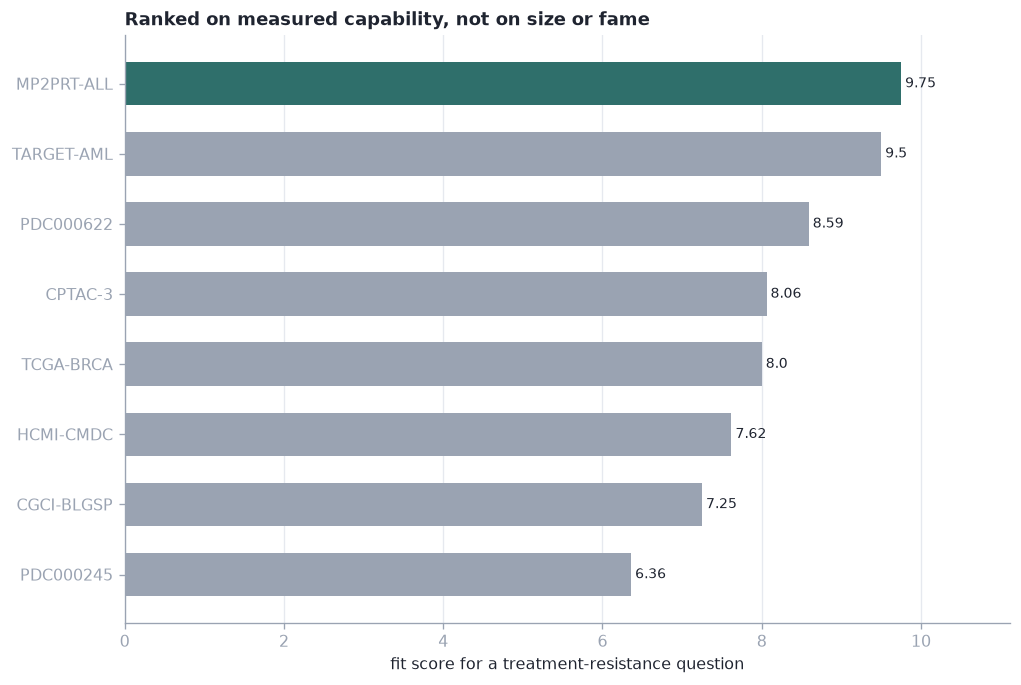

In [6]:
top = ranked.head(8).iloc[::-1]
colors = [ACCENT if t == choice["short_title"] else MUTED for t in top["short_title"]]
fig, ax = plt.subplots(figsize=(8.6, 0.5 * len(top) + 1.8))
ax.barh(top["short_title"], top["fit_score"], color=colors, height=0.62)
for i, v in enumerate(top["fit_score"]):
    ax.text(v, i, f" {v}", va="center", fontsize=8.5, color=INK)
ax.set_xlabel("fit score for a treatment-resistance question")
ax.set_xlim(0, float(top["fit_score"].max()) * 1.14)
ax.grid(axis="y", visible=False)
finish(ax, "Ranked on measured capability, not on size or fame")
plt.show()

## 4. Read the blocking limitations before committing

This is the step that distinguishes a careful agent from a fast one. Each dataset's
full record carries limitations graded by severity, and a `blocking` limitation means a
whole class of analysis is ruled out no matter how the model is specified.

In [7]:
record_path = INDEX_PATH.parent / "datasets" / f"{choice['id']}.json"
record = json.loads(record_path.read_text())

blocking = [l for l in record.get("limitations", []) if l["severity"] == "blocking"]
major = [l for l in record.get("limitations", []) if l["severity"] == "major"]

print(f"{choice['short_title']}: {len(blocking)} blocking, {len(major)} major limitations\n")
for l in blocking:
    print(f"BLOCKING [{l['kind']}]")
    print(f"  {l['statement'][:300]}")
    print(f"  rules out: {', '.join(l['affected_analyses'])}\n")

if not blocking:
    print("No blocking limitations recorded. Proceed, minding the major ones:\n")
    for l in major[:3]:
        print(f"  [{l['kind']}] {l['statement'][:190]}")

MP2PRT-ALL: 0 blocking, 4 major limitations

No blocking limitations recorded. Proceed, minding the major ones:

  [missing_data] Despite complete treatment-outcome coverage, the descriptive treatment fields are empty: treatment type, treatment given and therapeutic agents are all at 0%. The regimen field names the pro
  [missing_data] Cause of death is not recorded for any case, so competing risks cannot be separated.
  [ascertainment_bias] Participants are enrolled on cooperative-group trials, which select for access to a participating center and for eligibility criteria that exclude some patients. Outcomes in trial population


## 5. Emit a task brief

What an agent should hand to the next step: the dataset, the access route, the
questions it can support, and the constraints it must respect.

In [8]:
brief = {
    "dataset_id": record["id"],
    "title": record["title"],
    "selected_because": {
        "fit_score": float(choice["fit_score"]),
        "cases": record["cohort"].get("n_cases"),
        "median_followup_months": record["longitudinal"].get("median_followup_months"),
        "treatment_response_recorded": record["longitudinal"].get("has_treatment_response"),
        "access_tier": record["access"]["tier"],
        "reuse_gap_index": record["reuse_metrics"].get("reuse_gap_index"),
    },
    "access": {
        "mechanism": record["access"].get("mechanism"),
        "landing_page": record.get("landing_page_url"),
        "steps": [s["action"] for s in record.get("access_steps", [])],
    },
    "supported_questions": [q["question"] for q in record.get("useful_for", [])][:5],
    "must_not_do": [u["statement"] for u in record.get("inappropriate_uses", [])],
    "blocking_constraints": [
        {"kind": l["kind"], "rules_out": l["affected_analyses"]} for l in blocking
    ],
    "provenance": {
        "review_status": record["review"]["status"],
        "metadata_retrieved": record.get("retrieved_at"),
    },
}
print(json.dumps(brief, indent=2)[:2600])

{
  "dataset_id": "gdc-mp2prt-all",
  "title": "Molecular Profiling to Predict Response to Treatment for Acute Lymphoblastic Leukemia",
  "selected_because": {
    "fit_score": 9.75,
    "cases": 1510,
    "median_followup_months": 100.2,
    "treatment_response_recorded": true,
    "access_tier": "mixed",
    "reuse_gap_index": -1.661
  },
  "access": {
    "mechanism": "Data Access Request through dbGaP using an eRA Commons account; institutional signing official approval required",
    "landing_page": "https://portal.gdc.cancer.gov/projects/MP2PRT-ALL",
    "steps": [
      "Confirm which trial protocols the cohort draws from",
      "Scope with the 7,459 open-access files",
      "Submit a dbGaP data access request"
    ]
  },
  "supported_questions": [
    "Which genomic features predict failure of protocolised induction therapy in paediatric B-cell acute lymphoblastic leukaemia?",
    "Do Hispanic or Latino children carry a different genomic landscape or a different response prof

## What this demonstrates

The selection changed because the filter was a *measurement* rather than a description.
A size-ranked search returns the largest cohort; a capability-ranked search returns one
where the analysis is actually possible, and hands the next step an explicit list of
what the data cannot support.

Every field used here is in the published export, so any agent can do this without
scraping pages or guessing at what a dataset contains.